In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# function to load data
def load_data(file_path):
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        elif file_path.endswith('.json'):
            df = pd.read_json(file_path)
        elif file_path.endswith('.xlsx') or file_path.endswith('.xls'):
            df = pd.read_excel(file_path)
        else:
            print('Unsupported file format. Please use .csv, .json, or .xlsx')
            return None
        return df
    except Exception as e:
        print(f'An error occured: {e}')
        return None

filepath = 'dataset/Telco_customer_churn.xlsx'
data = load_data(filepath)
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
target_col = ['Churn Value']

drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Churn Label', 'Churn Score', 'Churn Reason']

numeric_cols = ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

categorical_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 
                    'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 
                    'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

def clean_attributes(dataset):
   # first let's remove the unnecessary columns from the set
    data_dropped_columns = dataset.drop(columns=drop_cols)

    # next separate the label from the features
    X = data_dropped_columns.drop(columns=target_col)
    y = data_dropped_columns[target_col[0]]

    # finally, let's change the Dtype for attribute 'Total Charges' from object to numeric
    X['Total Charges'] = pd.to_numeric(X['Total Charges'], errors='coerce')

    return [data_dropped_columns, X, y]

# drop the unrequired columns from the dataset
data_with_dropped_columns, X, y = clean_attributes(data)

print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Latitude           7043 non-null   float64
 1   Longitude          7043 non-null   float64
 2   Gender             7043 non-null   object 
 3   Senior Citizen     7043 non-null   object 
 4   Partner            7043 non-null   object 
 5   Dependents         7043 non-null   object 
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   object 
 8   Multiple Lines     7043 non-null   object 
 9   Internet Service   7043 non-null   object 
 10  Online Security    7043 non-null   object 
 11  Online Backup      7043 non-null   object 
 12  Device Protection  7043 non-null   object 
 13  Tech Support       7043 non-null   object 
 14  Streaming TV       7043 non-null   object 
 15  Streaming Movies   7043 non-null   object 
 16  Contract           7043 

In [4]:
y.value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

## < Set aside test set >

In [5]:
# split the data
from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train.shape: {X_train.shape}')
print(f'X_test.shape: {X_test.shape}')

X_train.shape: (5634, 22)
X_test.shape: (1409, 22)


## < EDA (let's see if we can gain some insights on the data) >

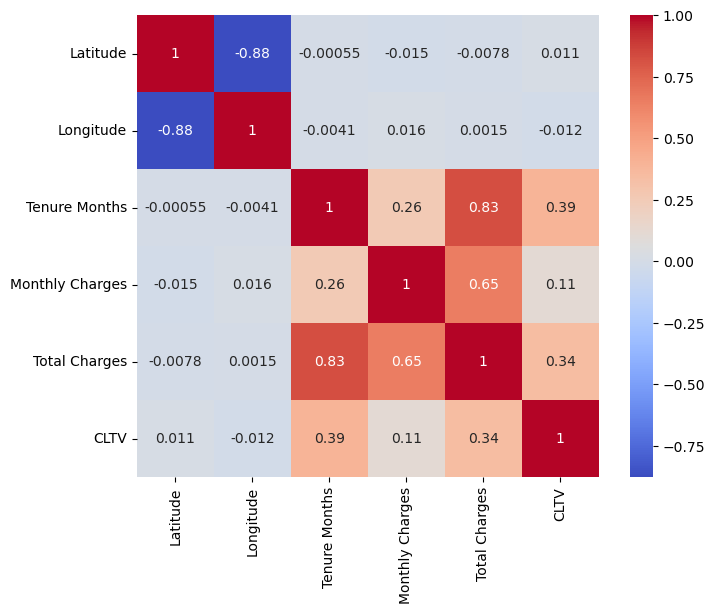

In [6]:
# Correlation between features
import seaborn as sns

# create a correlation matrix on the numerical attributes of the train set
corr_matrix = X_train[numeric_cols].corr()

# plot the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.show()

* latitude and longitude - have a strong negative correlation (-0.88)
* Total Charges and Tenure Months - have a strong positive correlation (0.83)
* Total Charges and Monthly Charges - have a moderate to high positive correlation (0.65)

We can either drop either one from the pairs, or combine to create new attributes since there's likely to be redundancy

In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 4626 to 6017
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Latitude           5634 non-null   float64
 1   Longitude          5634 non-null   float64
 2   Gender             5634 non-null   object 
 3   Senior Citizen     5634 non-null   object 
 4   Partner            5634 non-null   object 
 5   Dependents         5634 non-null   object 
 6   Tenure Months      5634 non-null   int64  
 7   Phone Service      5634 non-null   object 
 8   Multiple Lines     5634 non-null   object 
 9   Internet Service   5634 non-null   object 
 10  Online Security    5634 non-null   object 
 11  Online Backup      5634 non-null   object 
 12  Device Protection  5634 non-null   object 
 13  Tech Support       5634 non-null   object 
 14  Streaming TV       5634 non-null   object 
 15  Streaming Movies   5634 non-null   object 
 16  Contract           5634 no

In [8]:
# Check Columns with null values
null_columns = X_train.columns[X_train.isnull().any()].tolist()
print(X_train[null_columns].isnull().sum())

Total Charges    8
dtype: int64


* from .info() we'd seen kut Total Charges had some null values, so i ran that code to check if there was more that might have been missed
* for now it seems we only have 8 null values in the Total Charges column

In [9]:
X_train.describe()

,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV
count,5634.000000,5634.000000,5634.000000,5634.000000,5626.000000,5634.000000
mean,36.267457,-119.785395,32.485091,64.929961,2302.604266,4404.100639
std,2.462924,2.156997,24.568744,30.138105,2279.173176,1182.190717
min,32.555828,-124.301372,0.000000,18.400000,18.850000,2003.000000
25%,34.029043,-121.804783,9.000000,35.662500,407.275000,3470.250000
50%,36.319181,-119.690560,29.000000,70.500000,1398.125000,4528.000000
75%,38.197555,-118.032222,55.000000,90.000000,3838.612500,5380.750000
max,41.962127,-114.192901,72.000000,118.750000,8684.800000,6500.000000


* looking at the mean & std values, plus the min & max values it shows kut there's major differences in the scales between these features
* e.g for Standardization, there should be mean of 0 and unit std close to 1
* and min max scaling / normalization, the min and max values would be 0 and 1

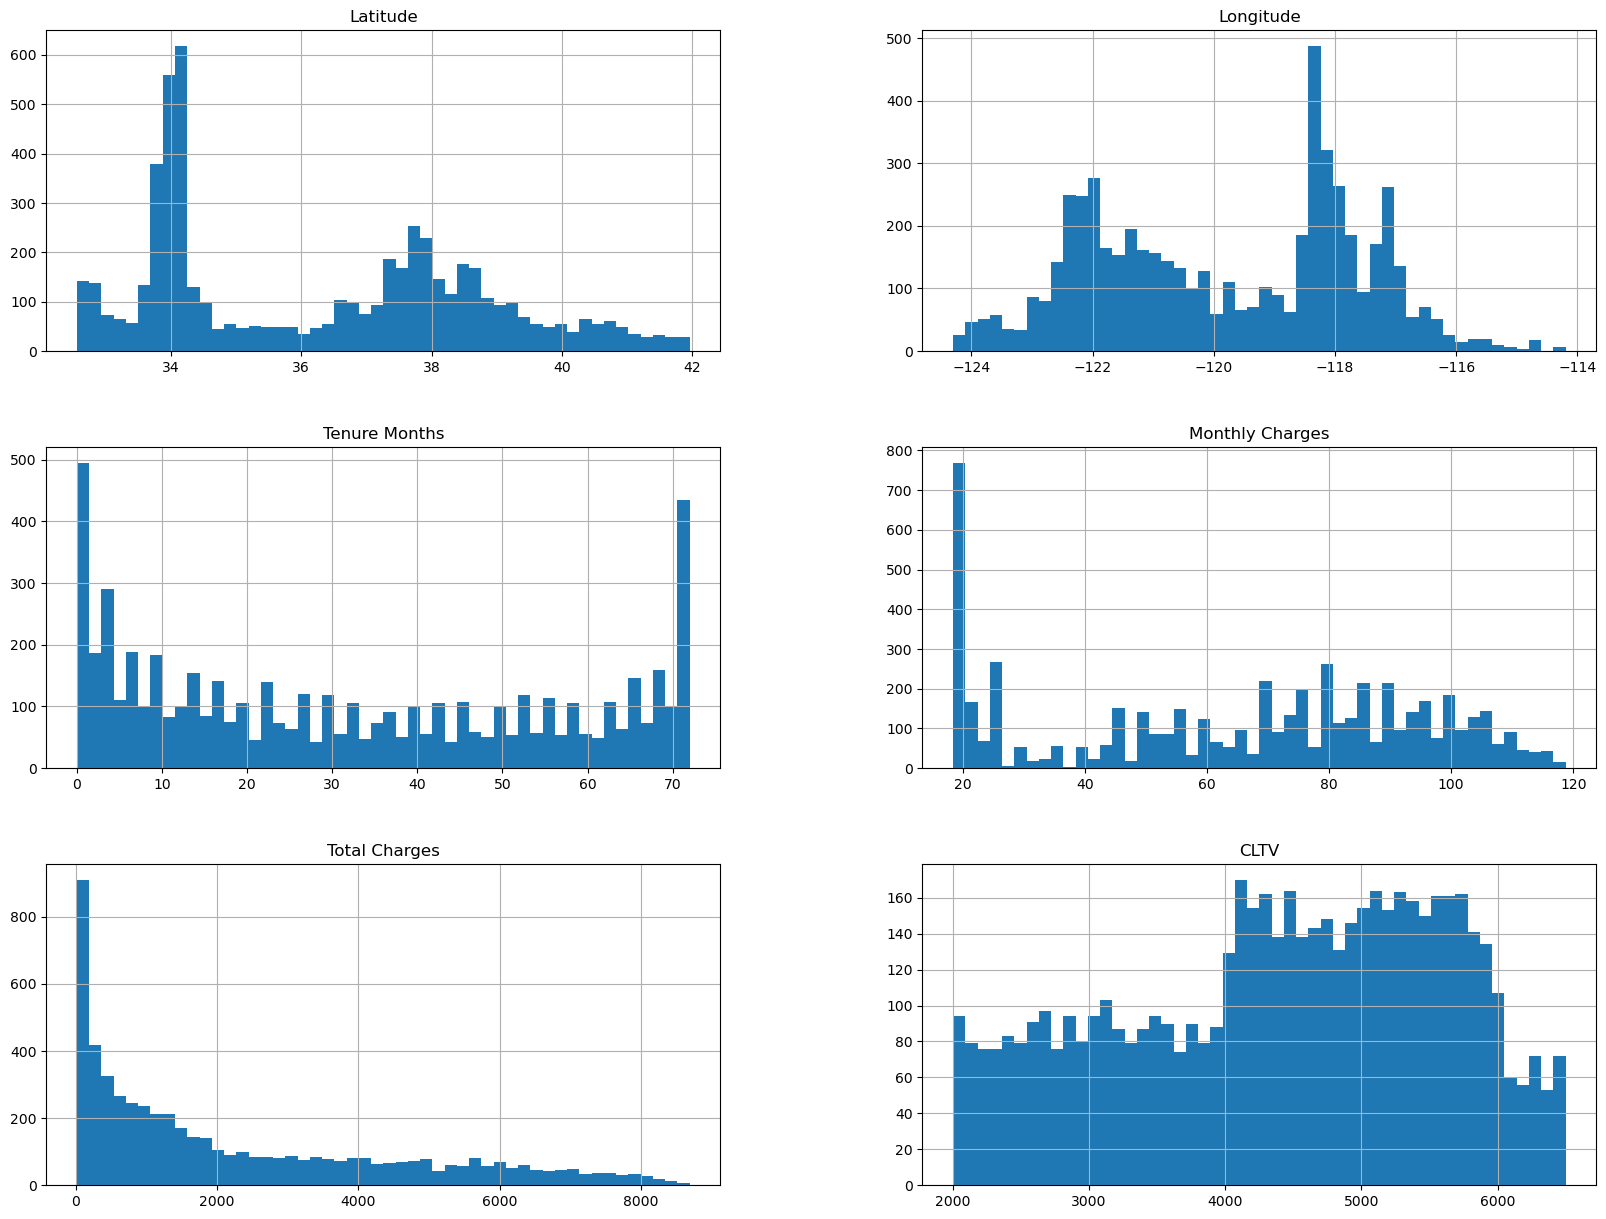

In [10]:
# histogram for quick visual analysis
X_train.hist(bins=50, figsize=(20, 15))
plt.show()

* those scales are standing out hahahaha
* i don't know about outliers that much but Total Charges seems to have a tail, or atleast skewed to the left

## < Prepare Data for ML algs >

In [9]:
# feature engineering and selection

# create a copy of X_train set, so we can experiment a bit with features
X_train_copy = X_train.copy()
X_train_copy['Tenure Monthly Interaction'] = X_train_copy['Tenure Months'] * X_train_copy['Monthly Charges']
X_train_copy['Tenure Total Interaction'] = X_train_copy['Tenure Months'] * X_train_copy['Total Charges']
X_train_copy['Charge Rate'] = X_train_copy['Monthly Charges'] / (X_train_copy['Tenure Months'] + 1) # +1 to prevent div by 0
X_train_copy['CLTV Ratio'] = X_train_copy['Total Charges'] / X_train_copy['CLTV']
# X_train_copy[''] = X_train_copy[''] / X_train_copy['']

# Geographic features
mean_lat, mean_lon = X_train_copy['Latitude'].mean(), X_train_copy['Longitude'].mean()
X_train_copy['Geo Distance'] = np.sqrt((X_train_copy['Latitude'] - mean_lat)**2 + (X_train_copy['Longitude'] - mean_lon)**2)

# Polynomial
X_train_copy['Monthly Charge sq'] = X_train_copy['Monthly Charges']**2

# drop redundant original features
# X_train_copy = X_train_copy.drop(columns=['Monthly Charges', 'Longitude', 'Total Charges'])

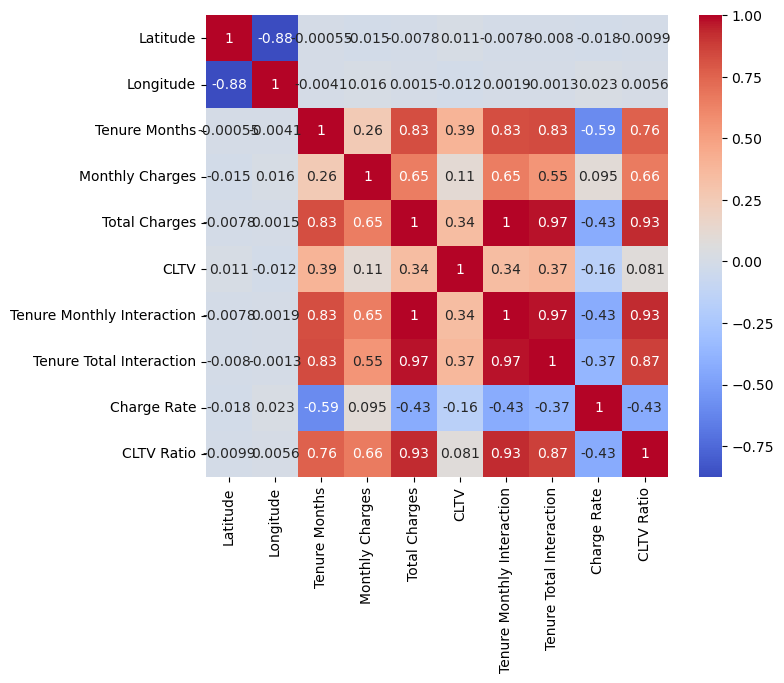

In [10]:
# create a correlation matrix on the numerical attributes of the train set
corr_matrix_2 = X_train_copy[['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Tenure Monthly Interaction', 'Tenure Total Interaction', 'Charge Rate', 'CLTV Ratio']].corr()

# plot the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', square=True)
plt.show()

* the correlatoins between the features, particularly the replacement with 'Average Monthly Charge' seem to be good but i don't know if it correlates well with our label

### Create our beautiful beautiful Pipeline

In [13]:
# let's create a Custom Transformer for my features
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, QuantileTransformer, PolynomialFeatures
# from imblearn.over_sampling import SMOTE

tenure_months_ix, total_charges_ix = 2, 4

class AttributeExtractor(BaseEstimator, TransformerMixin):
    def __init__(self): 
        pass
    
    def fit(self, X, y=None):
        return self  
    
    def transform(self, X, y=None):
        average_monthly_charge = X[:, total_charges_ix] / X[:, tenure_months_ix]
        # X = X.drop(columns=['Monthly Charges', 'Longitude', 'Total Charges'])
        return np.c_[X, average_monthly_charge]

        
# pipeline for numerical attributes
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    # ('attribs_extractor', AttributeExtractor()),
    ('scaler', StandardScaler()),
    # ('smote', SMOTE(random_state=42))
])


# ColumnTransfomer is a single Transformer that handles both numerical and categorical cols at the same time
# constructor requires a list of tuples in format -> (name, transformer, list_of_names_of_columns)
# remember we already have numeric_cols and categorical_cols we defined earlier
# numerical_attrbs = ['Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Tenure Monthly Interaction', 'Tenure Total Interaction', 'Charge Rate', 'CLTV Ratio']

full_pipeline = ColumnTransformer([
    ("num", numerical_pipeline, numeric_cols),
    ("cat", OneHotEncoder(), categorical_cols),
])

X_train_prepared = full_pipeline.fit_transform(X_train)

## < Model training & evaluation >

In [14]:
# let's train a logistic reg model, this is gonna be my baseline
from sklearn.linear_model import LogisticRegression

logistic_reg = LogisticRegression()
logistic_reg.fit(X_train_prepared, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred_one = logistic_reg.predict(X_train_prepared)
recall_score(y_train, y_pred_one)

0.585953177257525

In [18]:
y_probas = logistic_reg.predict_proba(X_train_prepared)
threshold = 0.30
y_proba_scores = y_probas[:, 1]
y_proba_thr = (y_proba_scores >= threshold)
recall_score(y_train, y_proba_thr)

0.7832775919732441

In [36]:
confusion_mtrx = confusion_matrix(y_train, y_proba_thr)
confusion_mtrx = confusion_mtrx / confusion_mtrx.sum(axis=1, keepdims=True)
confusion_mtrx

array([[0.77530805, 0.22469195],
       [0.21672241, 0.78327759]])

In [22]:
y_pred_score = logistic_reg.decision_function(X_train_prepared)
threshold = 0.40
y_pred_dec = (y_pred_score <= threshold)
recall_score(y_train, y_pred_dec)

0.5464882943143813

In [23]:
# ohh yeahhhh (In Mordecai and Rigby voice), we now have a working Logistic reg model
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

# let's try it out on a few instances of the training set
sample_X = X_test.iloc[:10]
sample_y = y_test.iloc[:10]

# preprocess
sample_X_prepared = full_pipeline.transform(sample_X)

# predict and evaluate
sample_y_pred = logistic_reg.predict(sample_X_prepared)
print('label: ', (list(sample_y)))
print('predictions: ', sample_y_pred)

# metrics
print(f'recall score: {recall_score(sample_y, sample_y_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(sample_y, sample_y_pred):.3f}')

label:  [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
predictions:  [0 1 0 0 0 1 0 0 0 0]
recall score: 0.000
ROC-AUC: 0.389


### Measuring Accuracy using cv

In [24]:
from sklearn.model_selection import cross_val_score
logistic_reg_scores = cross_val_score(logistic_reg, X_train_prepared, y_train, cv=5, scoring="recall")

def display_scores(scores):   
    print("Scores:", scores)   
    print(f"Mean: {scores.mean():.3f}")
    print(f"Standard deviation: {scores.std():.3f}")

display_scores(logistic_reg_scores)

Scores: [0.61538462 0.56187291 0.56521739 0.59197324 0.57859532]
Mean: 0.583
Standard deviation: 0.020


In [25]:
# let's try this on the augemented data
X_tr_copy_prepared = full_pipeline.fit_transform(X_train_copy)

from sklearn.model_selection import cross_val_score
logistic_reg_scores_copy = cross_val_score(logistic_reg, X_tr_copy_prepared, y_train, cv=5, scoring="recall")

display_scores(logistic_reg_scores_copy)

Scores: [0.61538462 0.56187291 0.56521739 0.59197324 0.57859532]
Mean: 0.583
Standard deviation: 0.020


In [34]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(logistic_reg, X_train_prepared, y_train, cv=5)
conf_matrix = confusion_matrix(y_train, y_train_pred)
conf_matrix = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)
conf_matrix

array([[0.89635178, 0.10364822],
       [0.4173913 , 0.5826087 ]])

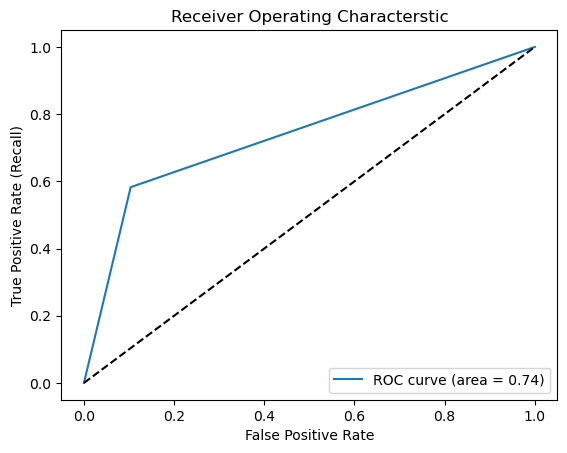

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score, auc
# print(precision_score(y_train, y_train_pred))
# print(recall_score(y_train, y_train_pred))
# print(f1_score(y_train, y_train_pred))
# print(roc_auc_score(y_train, y_train_pred))

fpr, tpr, thresholds = roc_curve(y_train, y_train_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characterstic')
plt.legend(loc='lower right')
plt.show()

### Model 2: Random Forest Classifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

# train
random_forest = RandomForestClassifier()
forest_scores = cross_val_score(random_forest, X_train_prepared, y_train, cv=5, scoring="recall")
display_scores(forest_scores)

Scores: [0.57525084 0.48160535 0.52173913 0.53511706 0.5083612 ]
Mean: 0.524
Standard deviation: 0.031


### Model 3: Decision Tree Classifier

In [130]:
from sklearn.tree import DecisionTreeClassifier

# train
decision_tree = DecisionTreeClassifier()
tree_scores = cross_val_score(decision_tree, X_train_prepared, y_train, cv=5, scoring="recall")
display_scores(tree_scores)

Scores: [0.52508361 0.50167224 0.52173913 0.57525084 0.51505017]
Mean: 0.528
Standard deviation: 0.025


### Model 4: SVM

In [131]:
from sklearn.svm import SVC

# train
vector_machine = SVC()
svm_scores = cross_val_score(vector_machine, X_train_prepared, y_train, cv=3, scoring="recall")
display_scores(svm_scores)

Scores: [0.56425703 0.50803213 0.52905812]
Mean: 0.534
Standard deviation: 0.023


### Model 5. Gradient Boost

In [132]:
from sklearn.ensemble import GradientBoostingClassifier

# train
gradient_boost = GradientBoostingClassifier()
boost_scores = cross_val_score(gradient_boost, X_train_prepared, y_train, cv=3, scoring="recall")
display_scores(boost_scores)

Scores: [0.57429719 0.53212851 0.56913828]
Mean: 0.559
Standard deviation: 0.019


## < Hyperparam Tuning (Fine-tuning) >

In [ ]:
from sklearn.model_selection import GridSearchCV

# let's define the hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [{0: 1, 1: v} for v in np.linspace(1, 3, 3)],
    'max_iter': [100, 1000]
}

grid_search = GridSearchCV(logistic_reg, param_grid, cv=10, scoring='recall', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train_prepared, y_train)

print('Best parameters: ', grid_search.best_params_)
print('Best score: ', grid_search.best_score_)